<a href="https://colab.research.google.com/github/vidhusree/ML-Project/blob/main/Day7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ANN

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [ ]:
iris=sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
le=LabelEncoder()
iris['species']=le.fit_transform(iris['species'])
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [ ]:
x=iris.drop('species',axis=1)
y=iris['species']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.25,random_state=12)
x_train.shape

(112, 4)

In [ ]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)


In [ ]:
model=Sequential()
model.add(Input(shape=(4,)))
model.add(Dense(10,activation='relu'))
model.add(Dense(3,activation='softmax'))


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))
loss,accuracy=model.evaluate(x_test,y_test)
print(f'loss:{loss},accuracy:{accuracy}')


Epoch 1/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9184 - loss: 0.2208 - val_accuracy: 0.9474 - val_loss: 0.2217
Epoch 2/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9087 - loss: 0.2278 - val_accuracy: 0.9474 - val_loss: 0.2174
Epoch 3/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9164 - loss: 0.2170 - val_accuracy: 0.9474 - val_loss: 0.2141
Epoch 4/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9248 - loss: 0.2071 - val_accuracy: 0.9737 - val_loss: 0.2104
Epoch 5/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9301 - loss: 0.1917 - val_accuracy: 0.9737 - val_loss: 0.2074
Epoch 6/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8883 - loss: 0.2748 - val_accuracy: 0.9737 - val_loss: 0.2050
Epoch 7/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9052 - loss: 0.2406 - val_accuracy: 0.9737 - val_loss: 0.2023
Epoch 8/100
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9272 - loss: 0.2033 - val_accuracy: 0.9737 - 

In [ ]:
predictions=model.predict(x_test)
predicted_classes=np.argmax(predictions,axis=1)
predicted_classes

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([0, 2, 0, 1, 2, 2, 2, 0, 2, 0, 1, 0, 0, 0, 2, 2, 2, 1, 0, 1, 0, 1,
       2, 1, 0, 2, 2, 1, 0, 0, 0, 1, 2, 0, 2, 0, 1, 1])

In [ ]:
new_data=np.array([[5.1,3.5,1.4,0.2],[6.0,2.7,4.2,1.3]])
new_data=scaler.transform(new_data)
predictions=model.predict(new_data)
predicted_classes=np.argmax(predictions,axis=1)
predicted_classes

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0, 1])

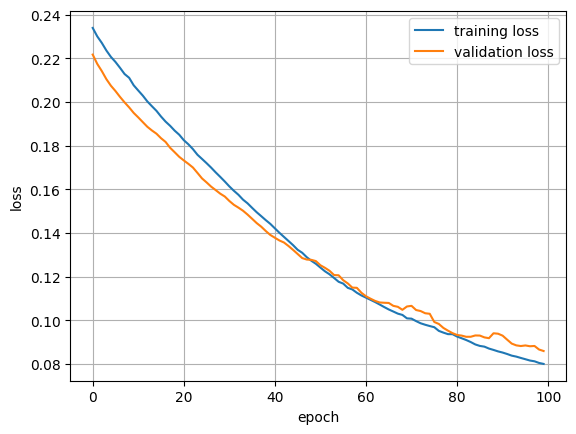

In [ ]:
import matplotlib.pyplot as plt
plt.plot(learned.history['loss'],label='training loss')
plt.plot(learned.history['val_loss'],label='validation loss')
plt.grid(True)
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [ ]:
###2

In [ ]:
df1=pd.read_csv('/content/Copy of breastcancer.csv')
df1.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df1.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df1.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,0.405172,1.216853,2.866059,40.337079,0.007041,0.025478,0.031894,0.011796,0.020542,0.003795,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,0.277313,0.551648,2.021855,45.491006,0.003003,0.017908,0.030186,0.006170,0.008266,0.002646,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,0.111500,0.360200,0.757000,6.802000,0.001713,0.002252,0.000000,0.000000,0.007882,0.000895,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,0.232400,0.833900,1.606000,17.850000,0.005169,0.013080,0.015090,0.007638,0.015160,0.002248,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,0.324200,1.108000,2.287000,24.530000,0.006380,0.020450,0.025890,0.010930,0.018730,0.003187,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,0.478900,1.474000,3.357000,45.190000,0.008146,0.032450,0.042050,0.014710,0.023480,0.004558,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,2.873000,4.885000,21.980000,542.200000,0.031130,0.135400,0.396000,0.052790,0.078950,0.029840,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [ ]:
df1.drop(columns=['id','Unnamed: 32'],axis=1,inplace=True)
df1.head()


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
df1['diagnosis'].nunique()

2

In [ ]:
le=LabelEncoder()
df1['diagnosis']=le.fit_transform(df1['diagnosis'])
df1.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


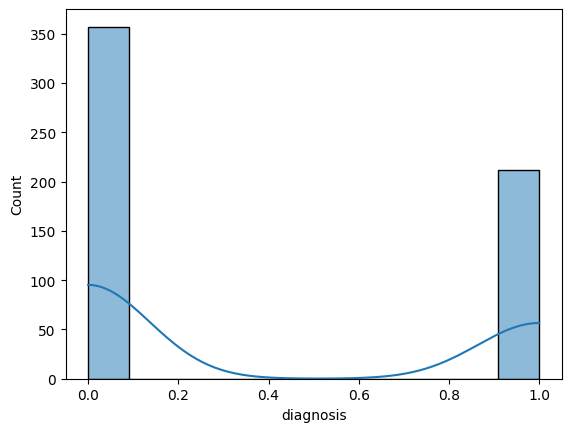

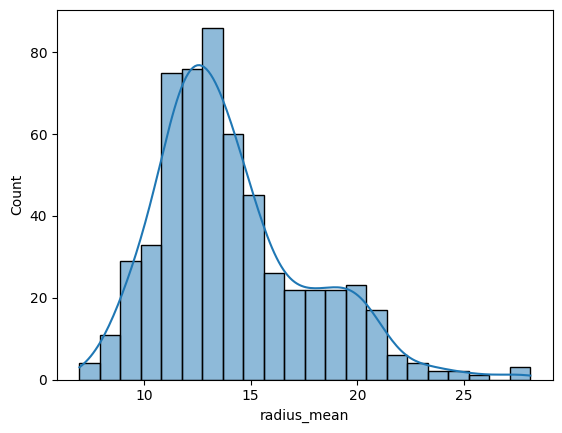

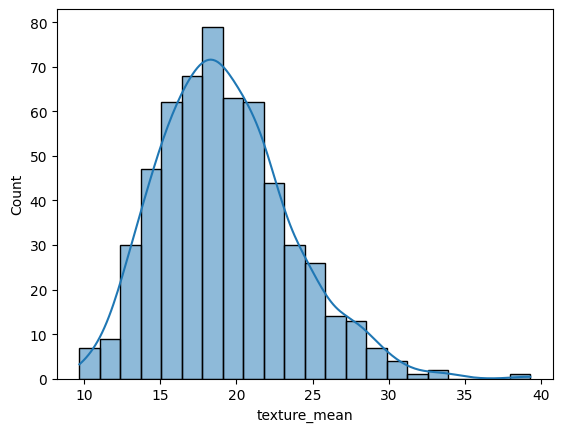

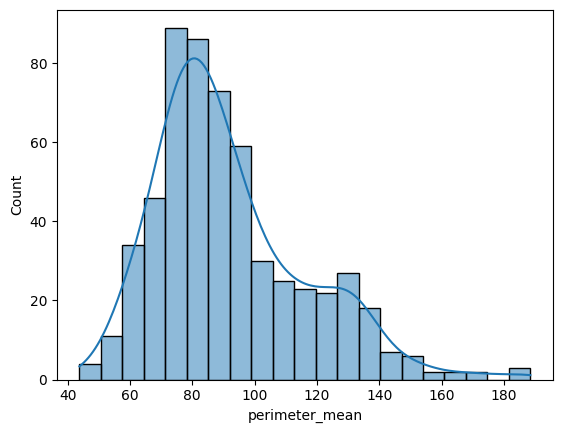

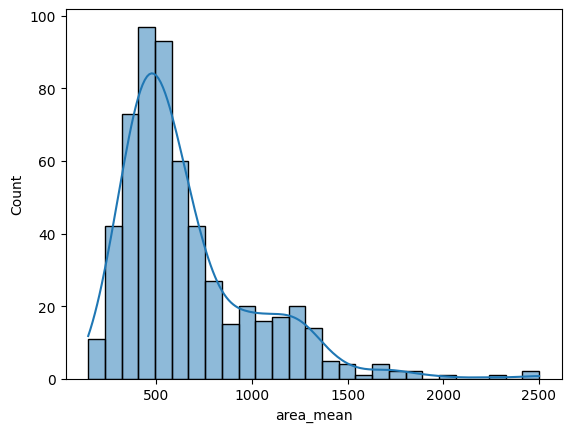

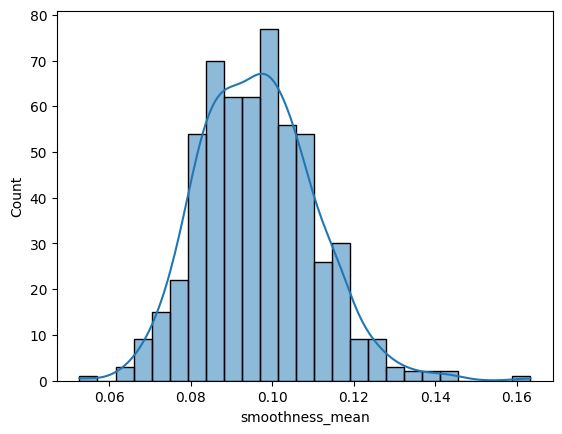

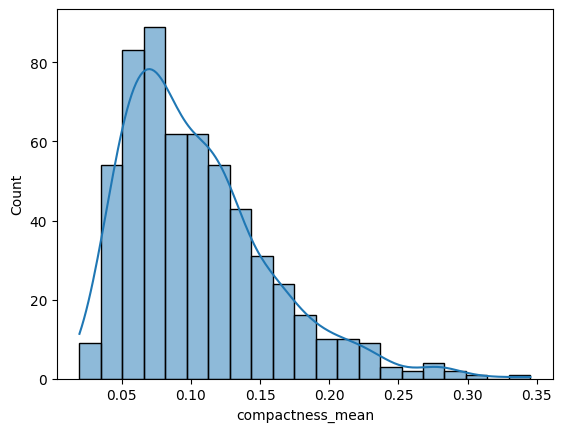

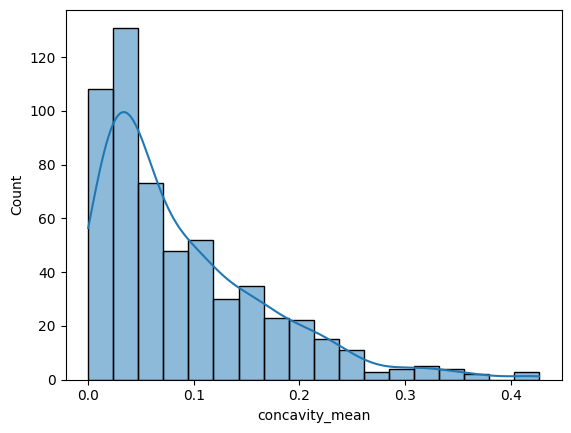

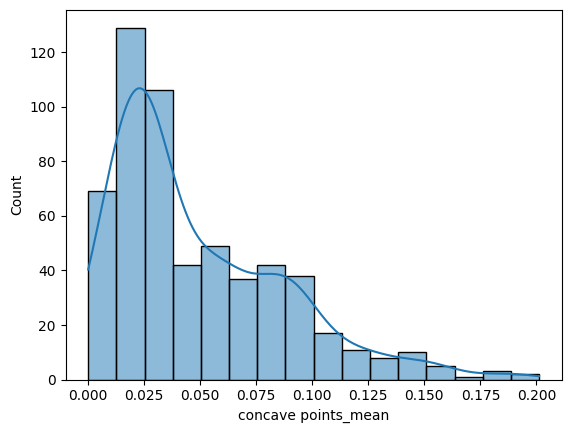

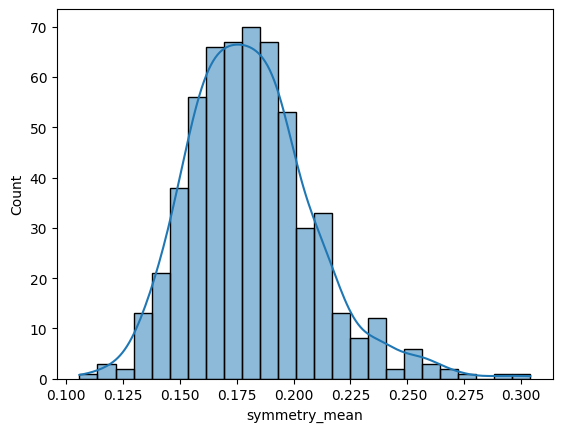

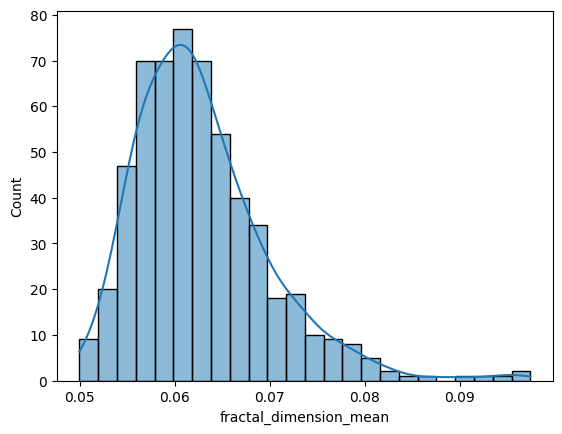

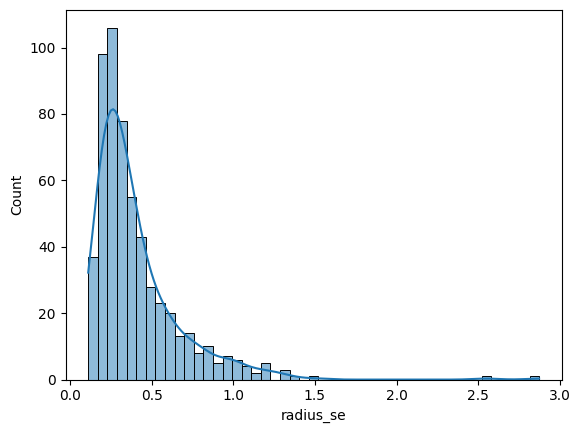

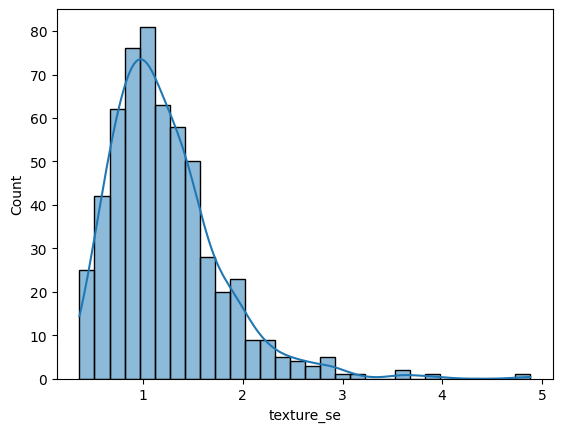

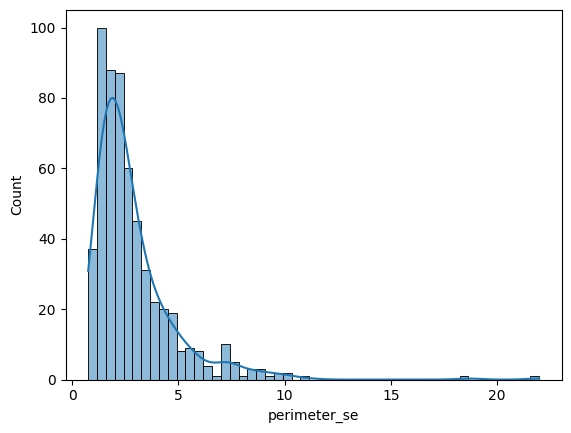

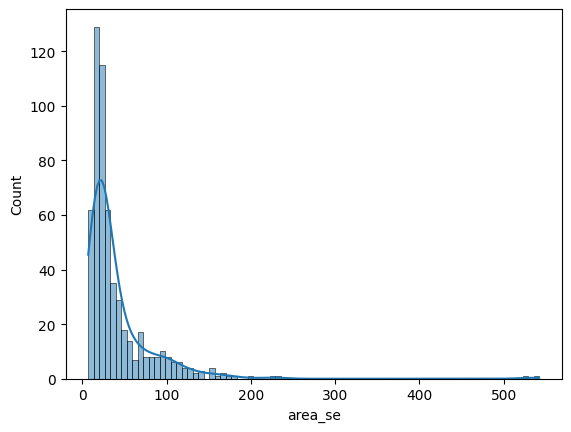

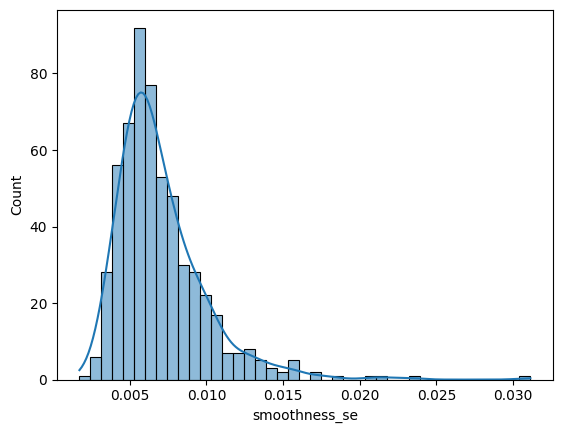

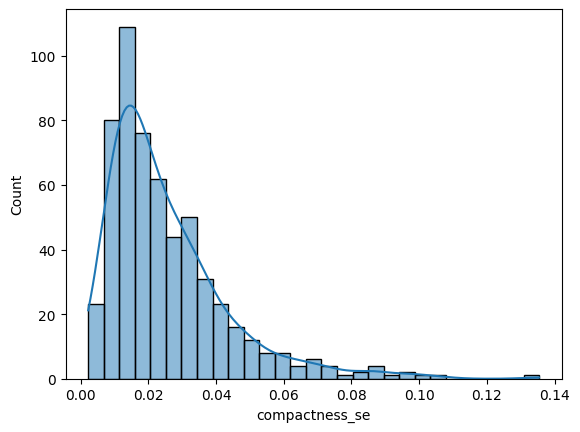

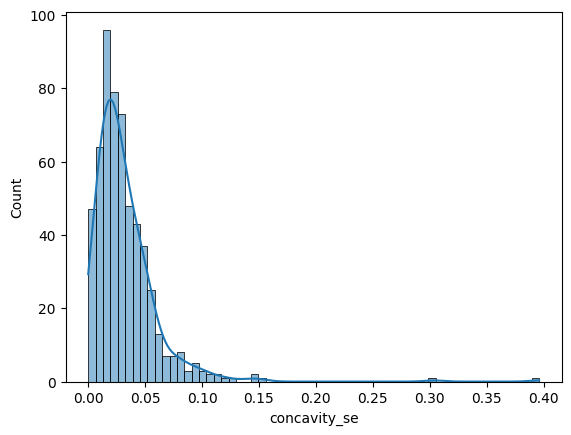

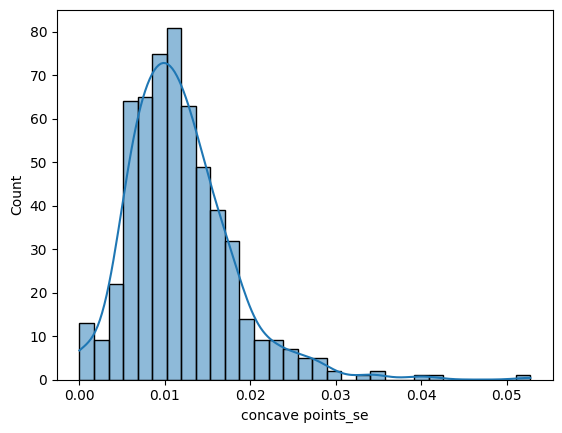

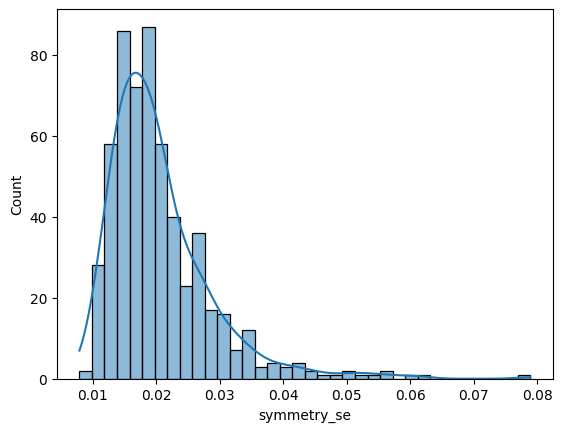

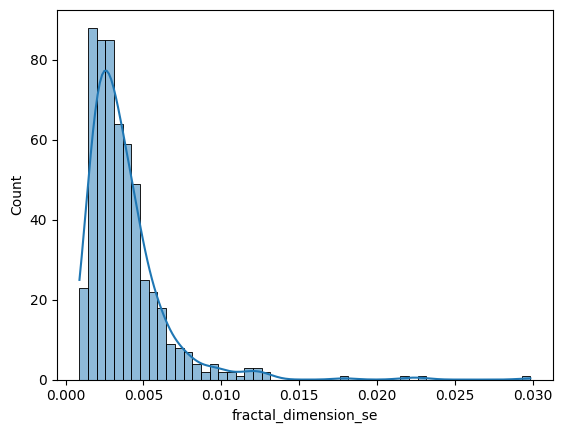

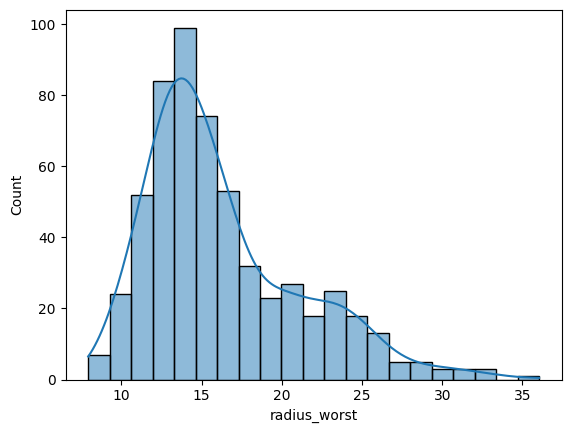

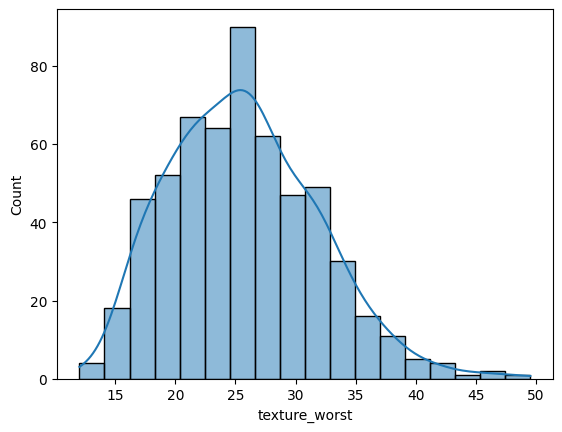

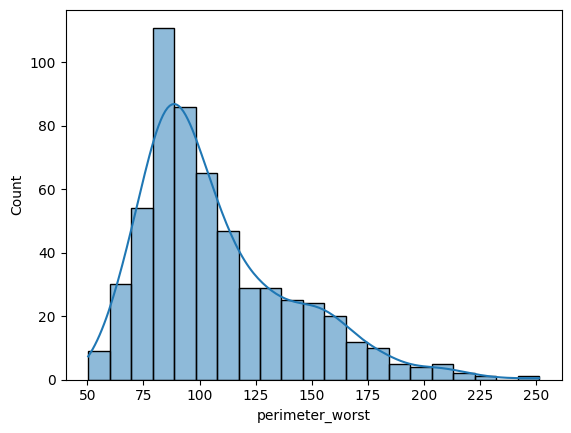

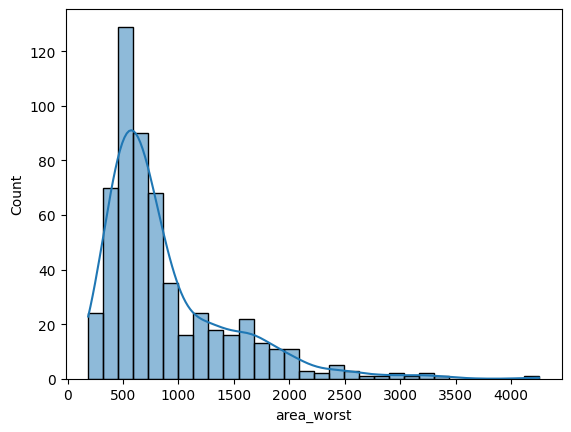

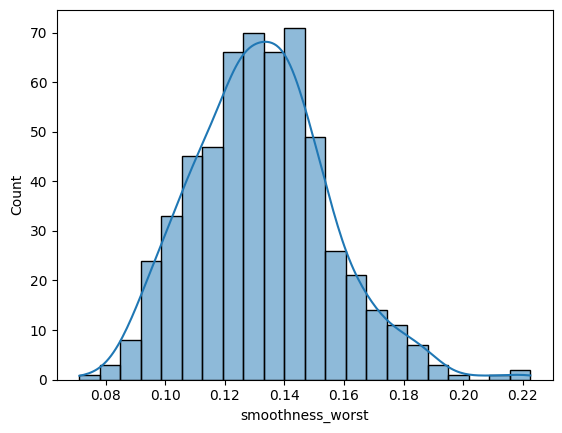

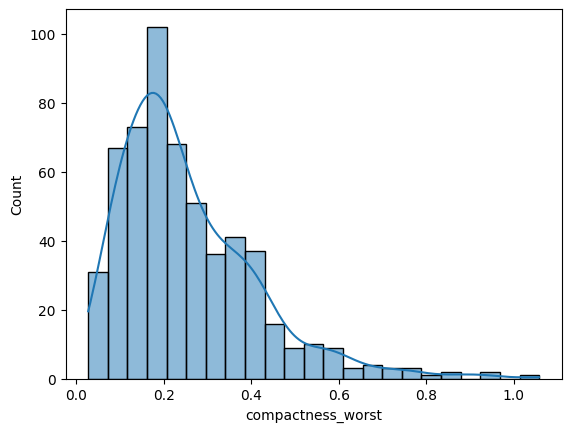

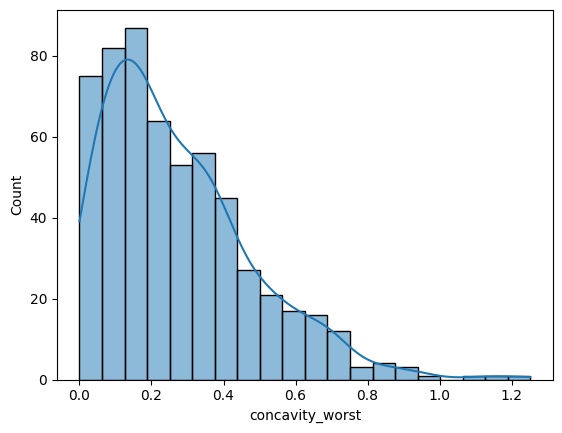

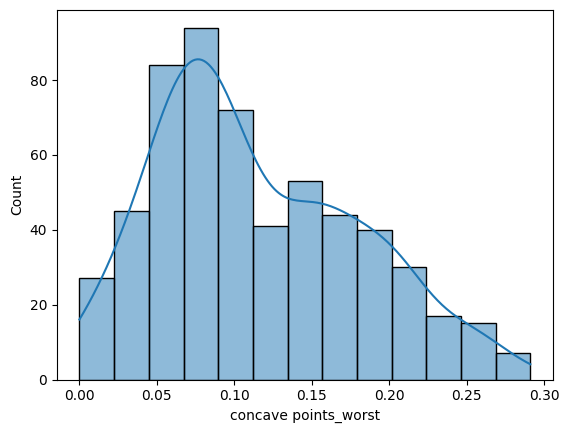

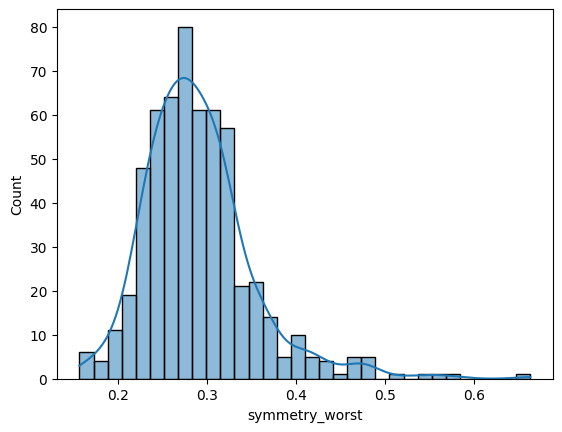

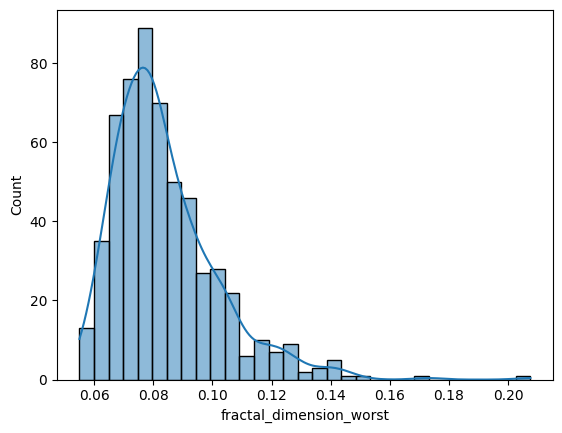

In [ ]:
numerical_cols=df1.select_dtypes(include=np.number).columns
for col in numerical_cols:
  sns.histplot(df1[col],kde=True)
  plt.show()

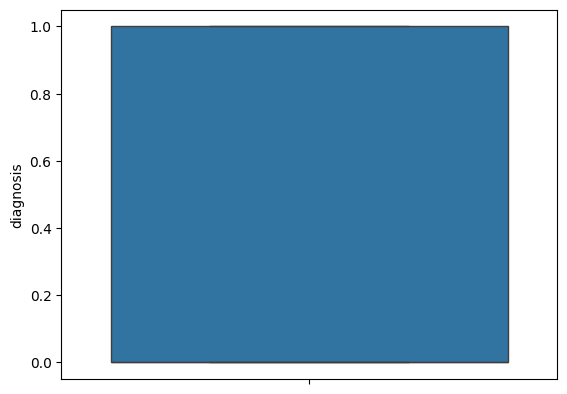

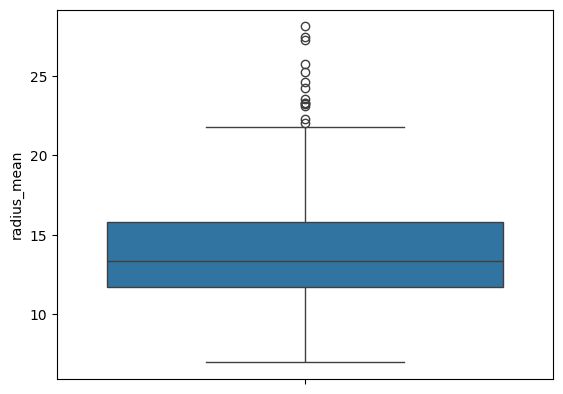

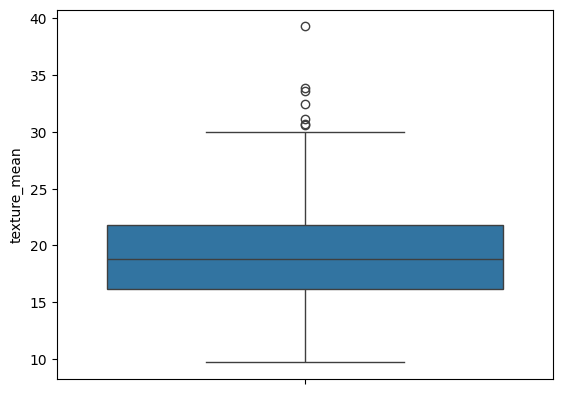

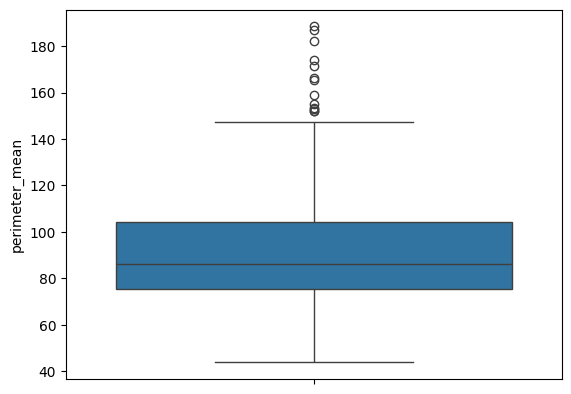

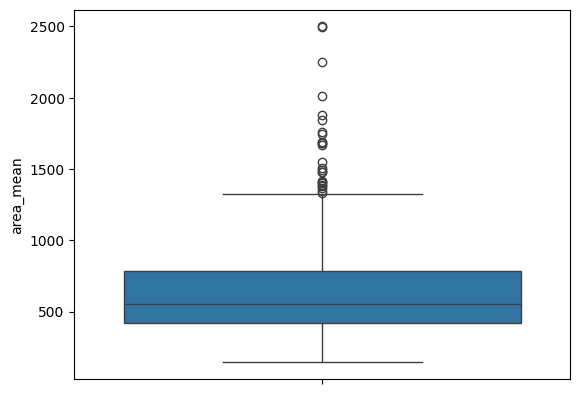

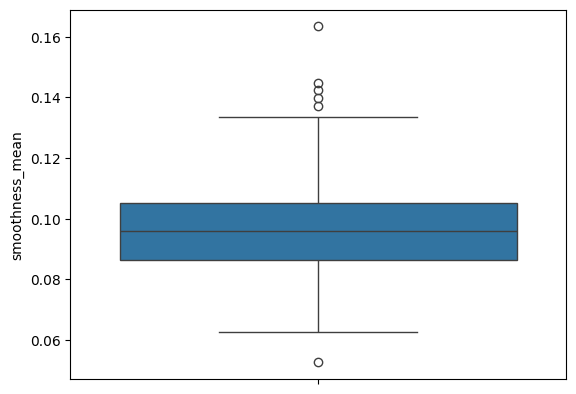

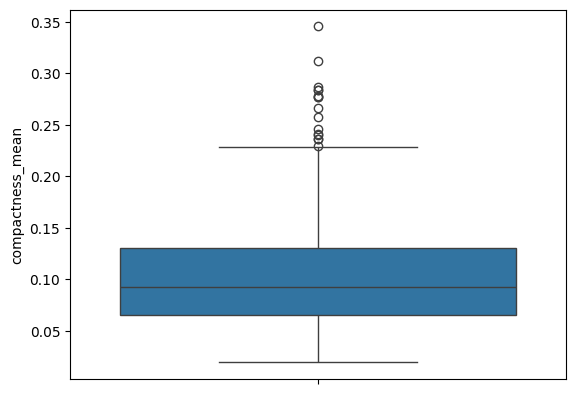

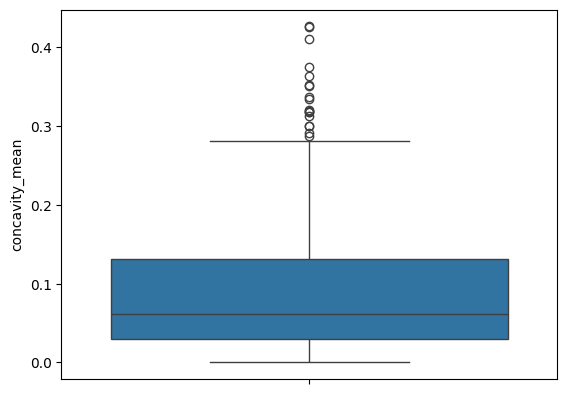

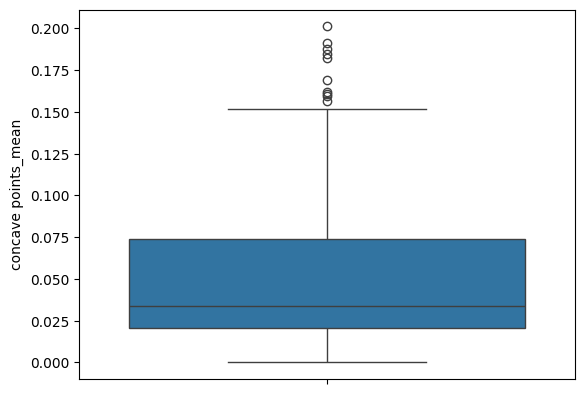

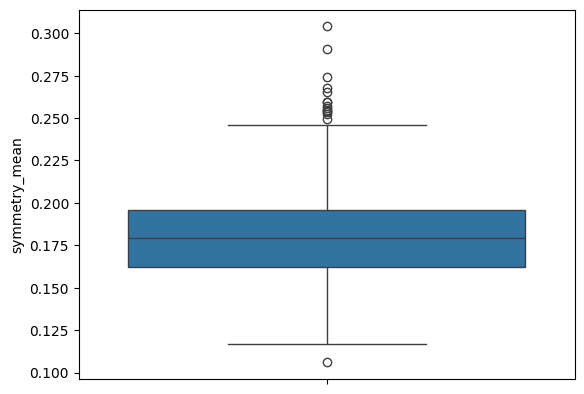

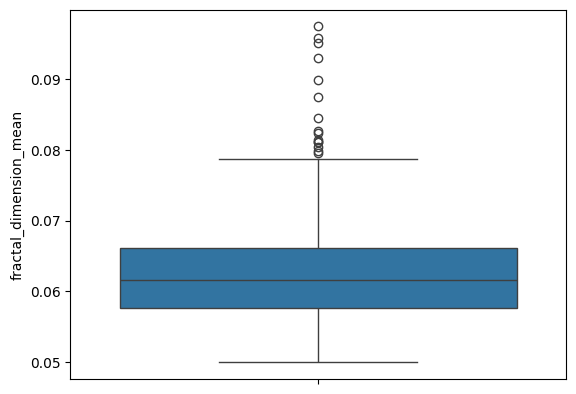

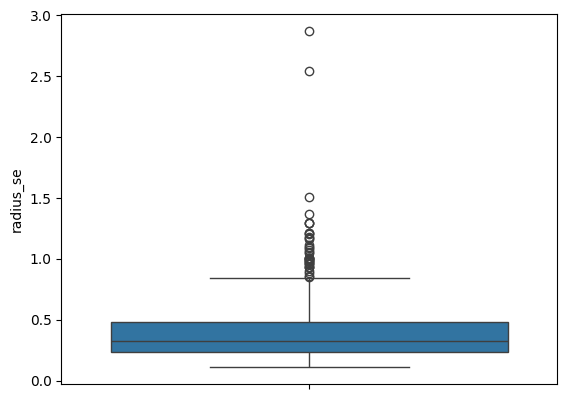

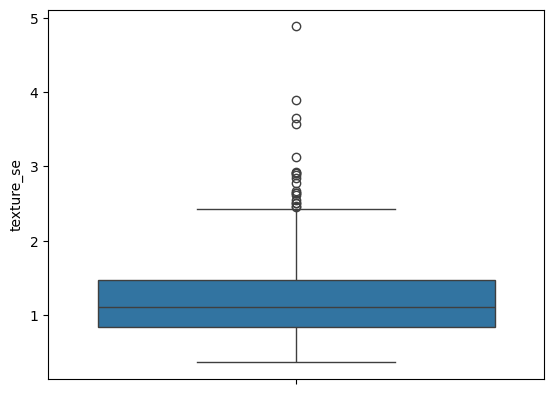

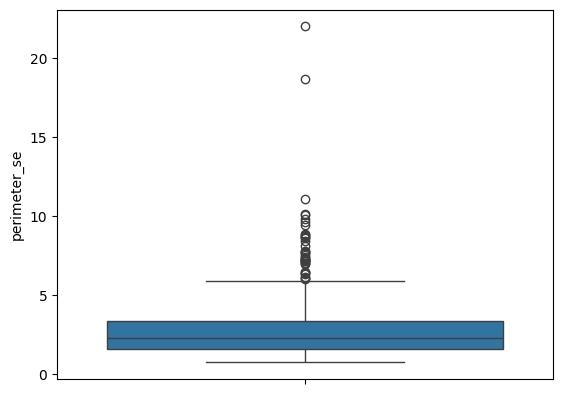

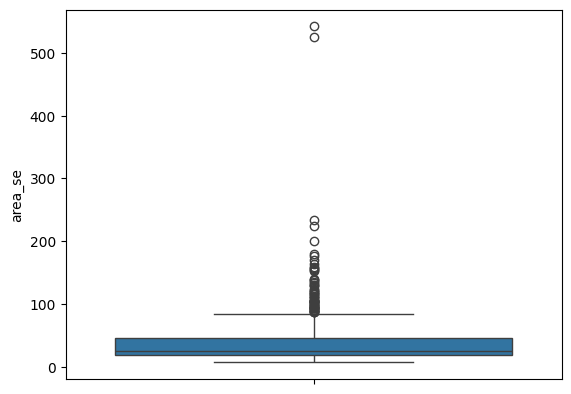

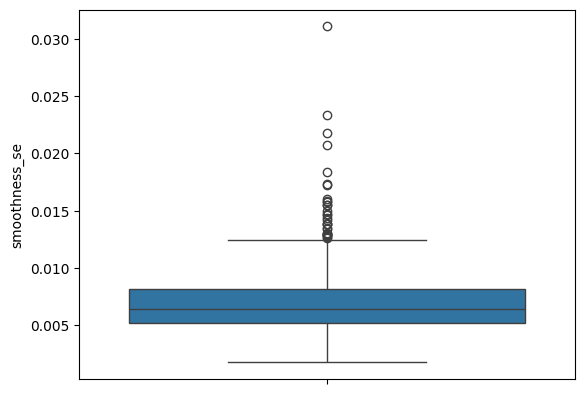

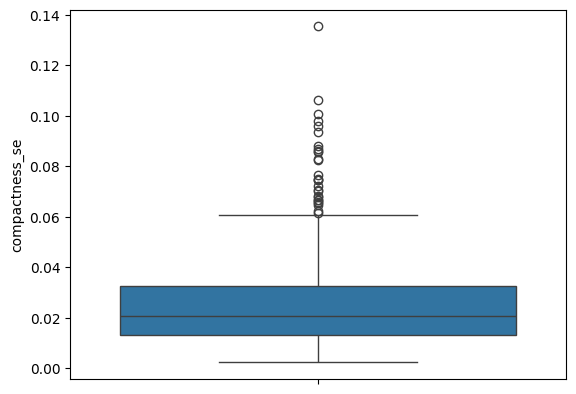

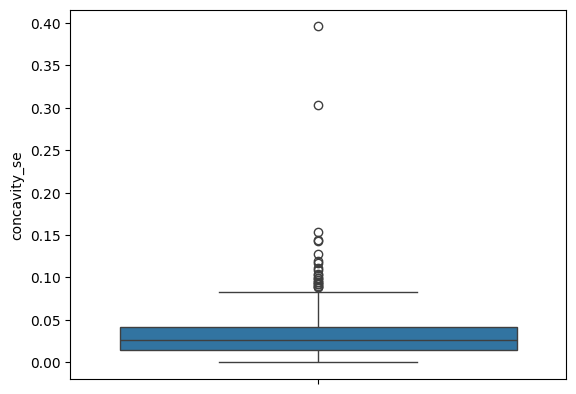

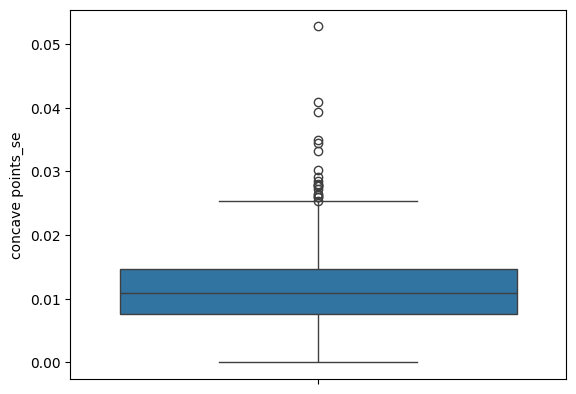

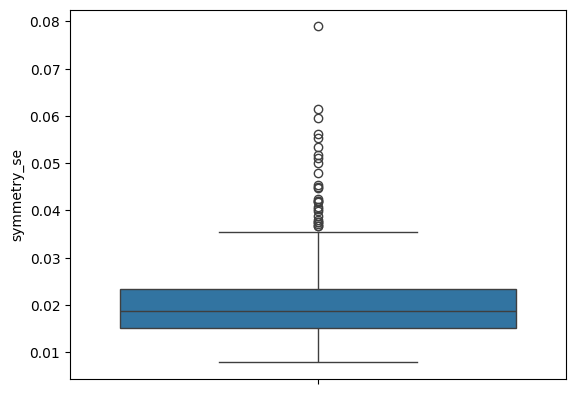

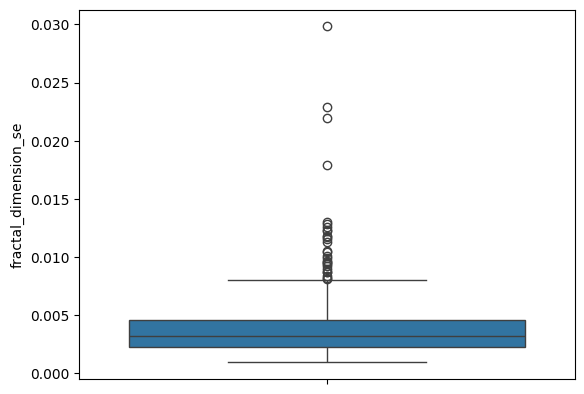

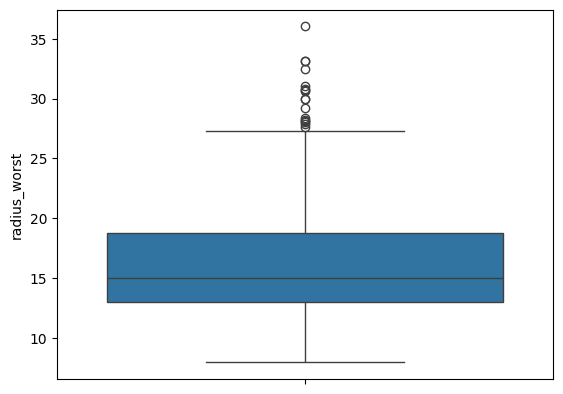

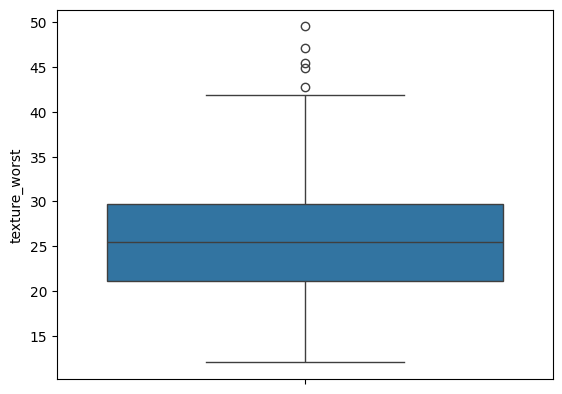

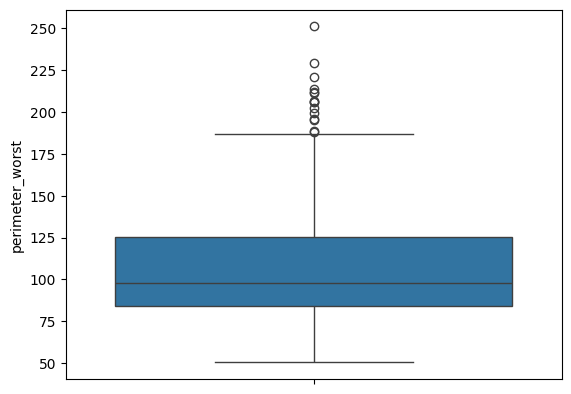

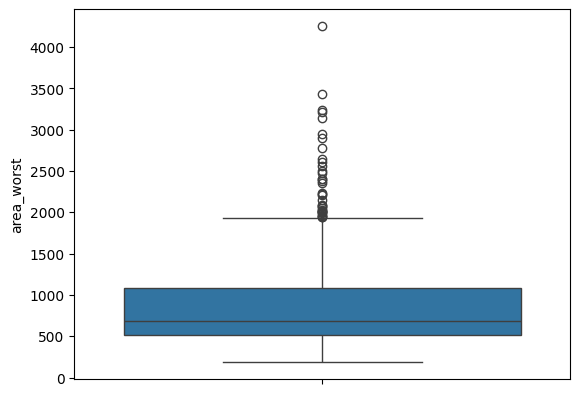

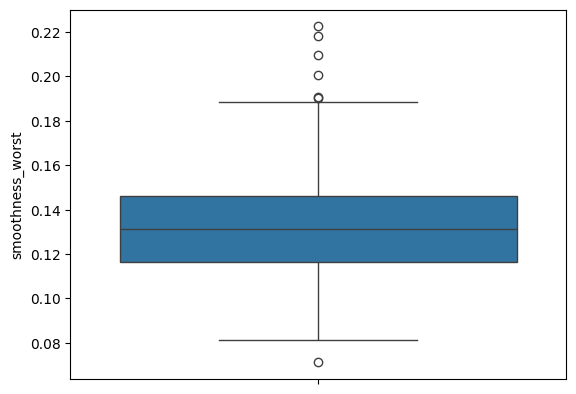

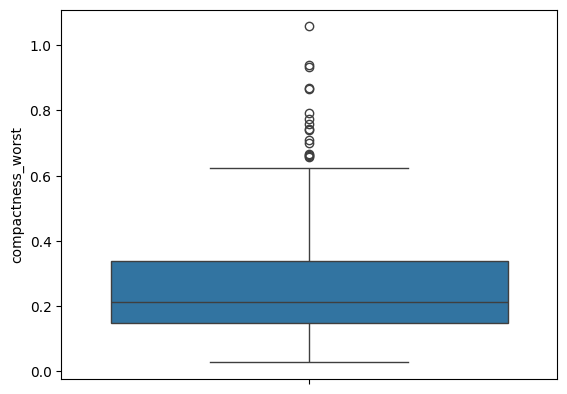

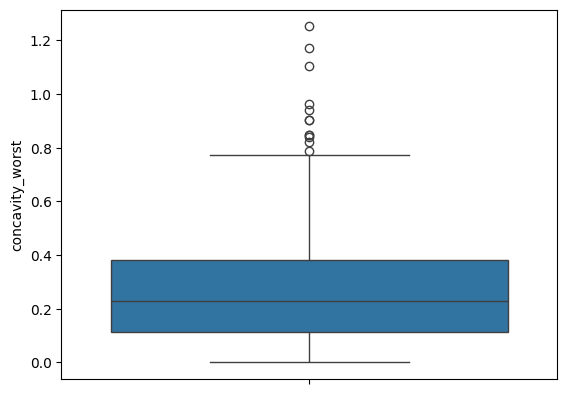

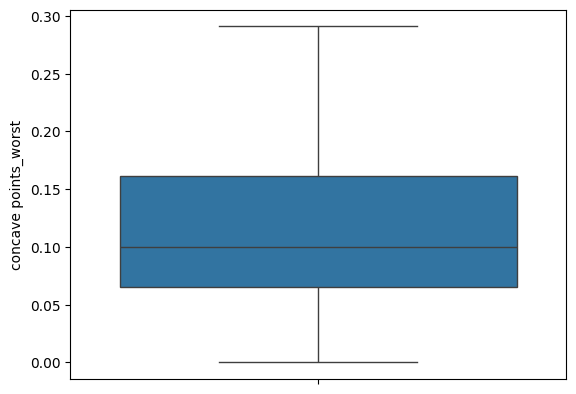

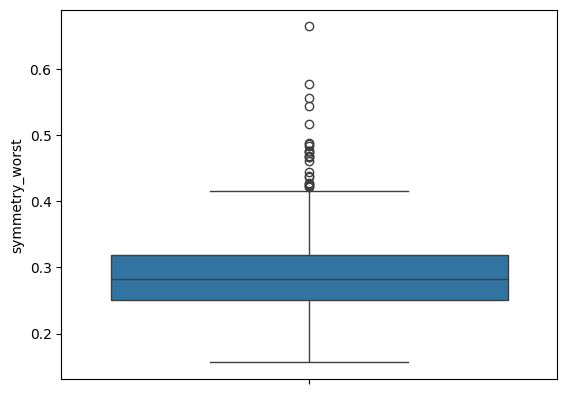

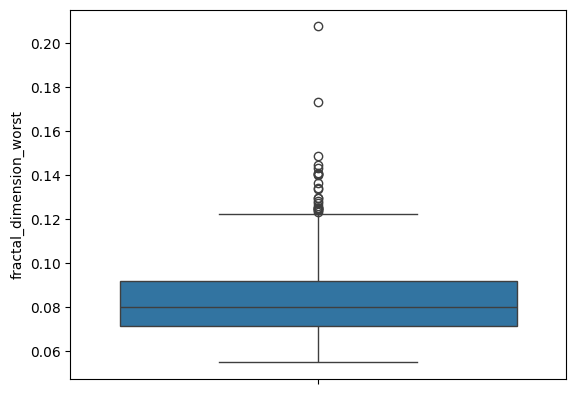

In [ ]:
numerical_cols=df1.select_dtypes(include=np.number).columns
for col in numerical_cols:
  sns.boxplot(df1[col])
  plt.show()

In [ ]:
from scipy.stats import skew
skew_values=df1[numerical_cols].skew()
print(skew_values)

diagnosis                  0.528461
radius_mean                0.942380
texture_mean               0.650450
perimeter_mean             0.990650
area_mean                  1.645732
smoothness_mean            0.456324
compactness_mean           1.190123
concavity_mean             1.401180
concave points_mean        1.171180
symmetry_mean              0.725609
fractal_dimension_mean     1.304489
radius_se                  3.088612
texture_se                 1.646444
perimeter_se               3.443615
area_se                    5.447186
smoothness_se              2.314450
compactness_se             1.902221
concavity_se               5.110463
concave points_se          1.444678
symmetry_se                2.195133
fractal_dimension_se       3.923969
radius_worst               1.103115
texture_worst              0.498321
perimeter_worst            1.128164
area_worst                 1.859373
smoothness_worst           0.415426
compactness_worst          1.473555
concavity_worst            1

In [ ]:
highly_skewed_cols=skew_values[skew_values>0.75].index
for col in highly_skewed_cols:
  if col !='diagnosis':
    df1[col]=np.log1p(df1[col])
display(df1[highly_skewed_cols].skew())

,0
radius_mean,0.348744
perimeter_mean,0.328800
area_mean,0.287328
compactness_mean,1.043195
concavity_mean,1.206982
concave points_mean,1.083180
fractal_dimension_mean,1.272294
radius_se,1.713417
texture_se,0.629526
perimeter_se,1.025375


<Axes: >

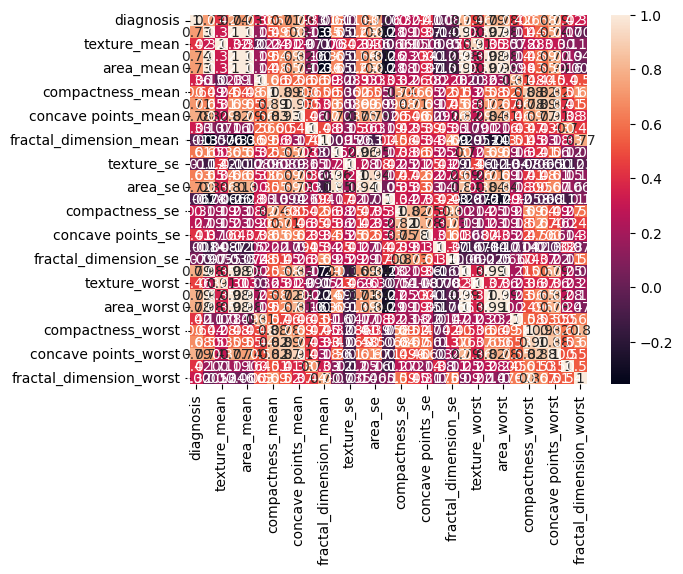

In [ ]:
import seaborn as sns
sns.heatmap(df1.corr(),annot=True)

In [ ]:
x=df1.drop('diagnosis',axis=1)
y=df1['diagnosis']

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)

In [ ]:
x_train.shape

(426, 30)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)


In [ ]:
model=Sequential()
model.add(Input(shape=(30,)))
model.add(Dense(10,activation='relu'))
model.add(Dense(2,activation='sigmoid'))


In [ ]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))
loss,accuracy=model.evaluate(x_test,y_test)
print(f'loss:{loss},accuracy:{accuracy}')

Epoch 1/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.8146 - loss: 0.4148 - val_accuracy: 0.9021 - val_loss: 0.2445
Epoch 2/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8742 - loss: 0.3140 - val_accuracy: 0.9301 - val_loss: 0.1816
Epoch 3/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9623 - loss: 0.1646 - val_accuracy: 0.9441 - val_loss: 0.1459
Epoch 4/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9513 - loss: 0.1696 - val_accuracy: 0.9650 - val_loss: 0.1197
Epoch 5/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9594 - loss: 0.1465 - val_accuracy: 0.9580 - val_loss: 0.1026
Epoch 6/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9477 - loss: 0.1405 - val_accuracy: 0.9650 - val_loss: 0.0911
Epoch 7/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9469 - loss: 0.1137 - val_accuracy: 0.9720 - val_loss: 0.0804
Epoch 8/100
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9562 - loss: 0.1008 - val_accuracy: 0.9720 - 

In [ ]:
###3

In [2]:
df2=sns.load_dataset('penguins')
df2

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [3]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [4]:
df2.describe()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


In [5]:
df2.isnull().sum()

,0
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [6]:
df2['sex']=df2['sex'].fillna(df2['sex'].mode())
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


In [7]:
df2.dropna(subset=['bill_length_mm','flipper_length_mm'],inplace=True)

In [8]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 21.4+ KB


In [10]:
from scipy.stats import skew
cat_value=df2.select_dtypes(include=["object"]).columns
num_value=df2.select_dtypes(include=["int64",'float64']).columns
skew_values=df2[num_value].skew()
print(skew_values)

bill_length_mm       0.053118
bill_depth_mm       -0.143465
flipper_length_mm    0.345682
body_mass_g          0.470329
dtype: float64


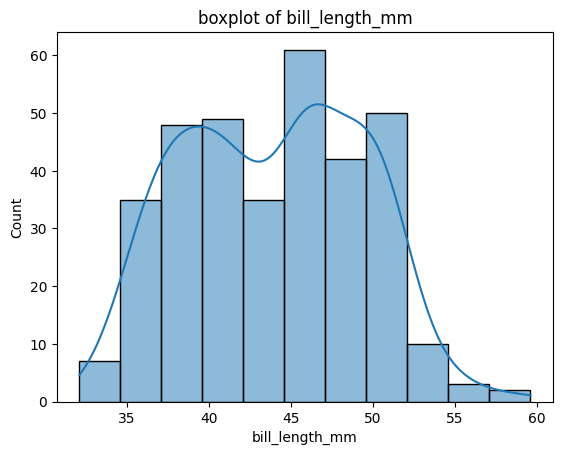

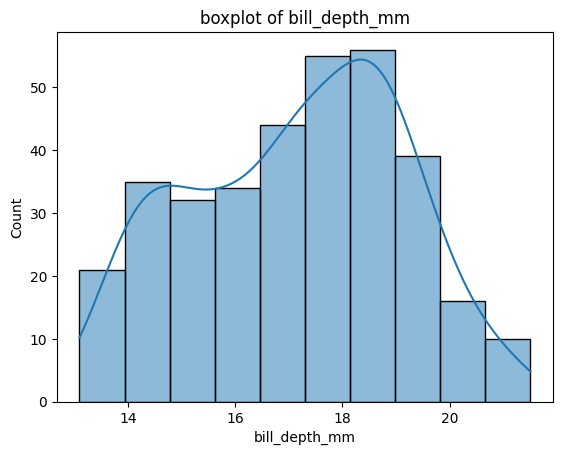

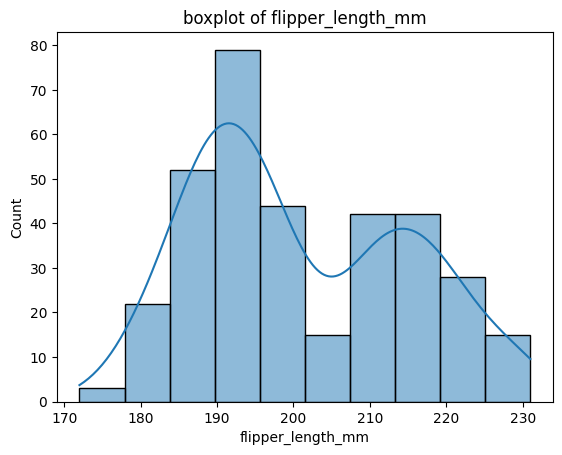

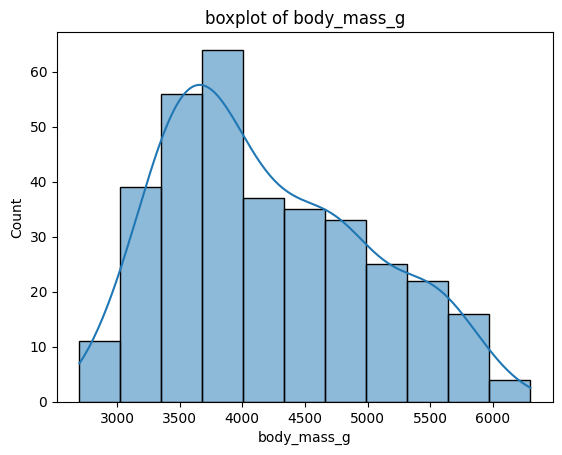

In [14]:
import matplotlib.pyplot as plt
numerical_cols=df2.select_dtypes(include=np.number).columns
for col in numerical_cols:
  sns.histplot(df2[col],kde=True)
  plt.title(f'boxplot of {col}')
  plt.show()

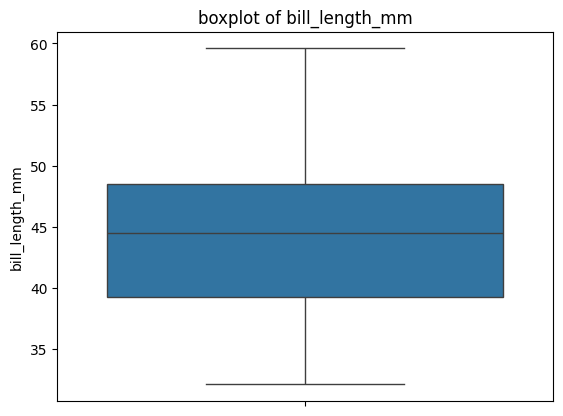

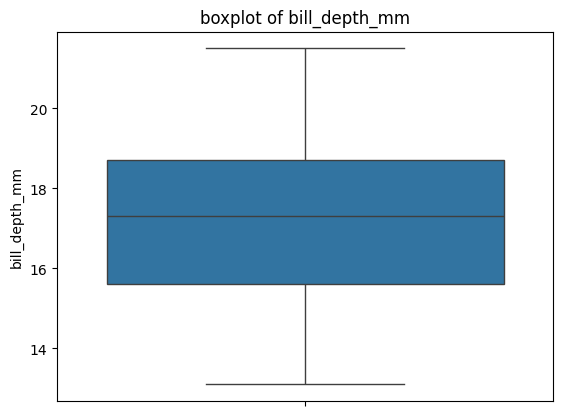

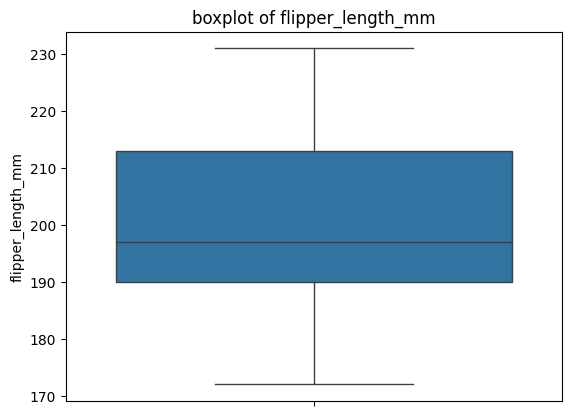

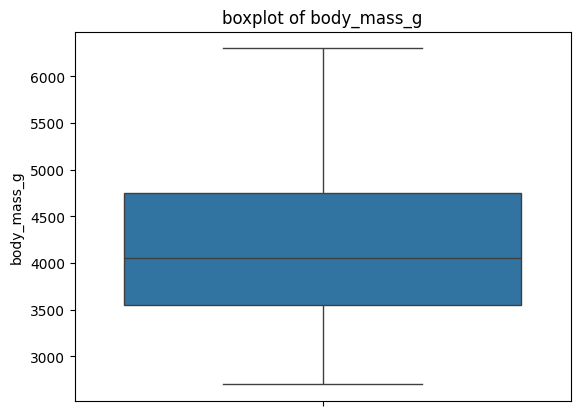

In [16]:
import matplotlib.pyplot as plt
numerical_cols=df2.select_dtypes(include=np.number).columns
for col in numerical_cols:
  sns.boxplot(df2[col])
  plt.title(f'boxplot of {col}')
  plt.show()

In [18]:
le=LabelEncoder()
df2['sex']=le.fit_transform(df2['sex'])

In [19]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 342 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            342 non-null    object 
 1   island             342 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                342 non-null    int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 21.4+ KB


In [20]:
#one hot
df2=pd.get_dummies(df2,columns=['island'],prefix="island",drop_first=True)
df2.head()

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,island_Dream,island_Torgersen
0,Adelie,39.1,18.7,181.0,3750.0,1,False,True
1,Adelie,39.5,17.4,186.0,3800.0,0,False,True
2,Adelie,40.3,18.0,195.0,3250.0,0,False,True
4,Adelie,36.7,19.3,193.0,3450.0,0,False,True
5,Adelie,39.3,20.6,190.0,3650.0,1,False,True


In [21]:
bol_cols=df2.select_dtypes(include='bool').columns
df2[bol_cols]=df2[bol_cols].astype(int)


In [26]:
ss=StandardScaler()
df2['body_mass_g']=ss.fit_transform(df2[['body_mass_g']])
df2['flipper_length_mm']=ss.fit_transform(df2[['flipper_length_mm']])

In [27]:
le=LabelEncoder()
df2['species']=le.fit_transform(df2['species'])

In [29]:
from sklearn.model_selection import train_test_split
y=df2['body_mass_g']
x=df2.drop('body_mass_g',axis=1)
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=12)

In [30]:
print(x_train.shape)
print(x_test.shape)

(256, 7)
(86, 7)


In [31]:
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [32]:
model=Sequential()
model.add(Input(shape=(x_train.shape[1],)))
model.add(Dense(10,activation='relu'))
model.add(Dense(1))

In [33]:
model.compile(optimizer='adam',loss='mae',metrics=['mae'])
learned=model.fit(x_train,y_train,epochs=100,batch_size=10,verbose=1,validation_data=(x_test,y_test))
loss,mae=model.evaluate(x_test,y_test)
print(f'loss:{loss},mae:{mae}')

Epoch 1/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - loss: 0.6970 - mae: 0.6970 - val_loss: 0.6301 - val_mae: 0.6301
Epoch 2/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.6624 - mae: 0.6624 - val_loss: 0.5815 - val_mae: 0.5815
Epoch 3/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.6097 - mae: 0.6097 - val_loss: 0.5406 - val_mae: 0.5406
Epoch 4/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.5286 - mae: 0.5286 - val_loss: 0.5091 - val_mae: 0.5091
Epoch 5/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - loss: 0.5021 - mae: 0.5021 - val_loss: 0.4772 - val_mae: 0.4772
Epoch 6/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.4507 - mae: 0.4507 - val_loss: 0.4494 - val_mae: 0.4494
Epoch 7/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.4573 - mae: 0.4573 - val_loss: 0.4231 - val_mae: 0.4231
Epoch 8/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4191 - mae: 0.4191 - val_loss: 0.4056 - val_mae: 0.4056
Epoch 9/100
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss

In [34]:
predictions=model.predict(x_test)
predictions_class=np.argmax(predictions,axis=1)
predictions_class

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

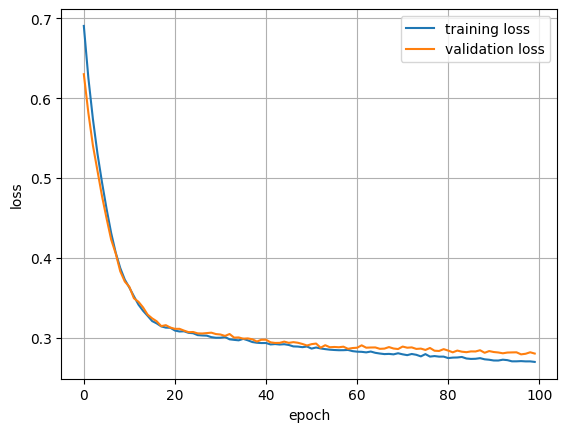

In [35]:
plt.plot(learned.history['loss'],label='training loss')
plt.plot(learned.history['val_loss'],label='validation loss')
plt.grid(True)
plt.legend()
plt.xlabel('epoch')
plt.ylabel('loss')
plt.show()

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 10)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 275 (1.08 KB)

 Trainable params: 91 (364.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 184 (740.00 B)

In [37]:
##4
df=sns.load_dataset('diamonds')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [38]:
df.isna().sum()

,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


In [39]:
from scipy.stats import skew
cat_value=df.select_dtypes(include=["object"]).columns
num_value=df.select_dtypes(include=["int64","float64"]).columns

skew_value=df[num_value].skew()
skew_value


,0
carat,1.116646
depth,-0.082294
table,0.796896
price,1.618395
x,0.378676
y,2.434167
z,1.522423


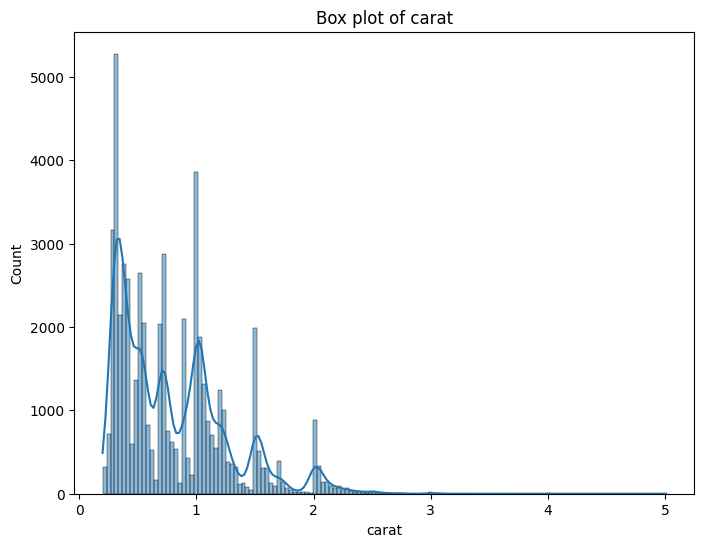

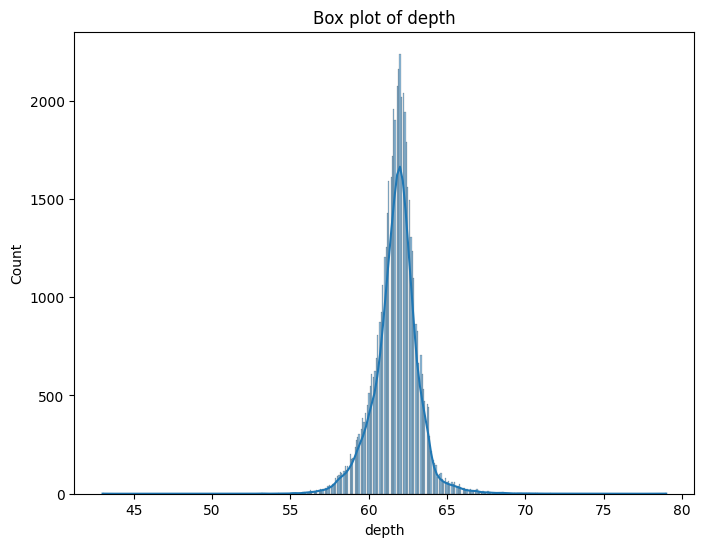

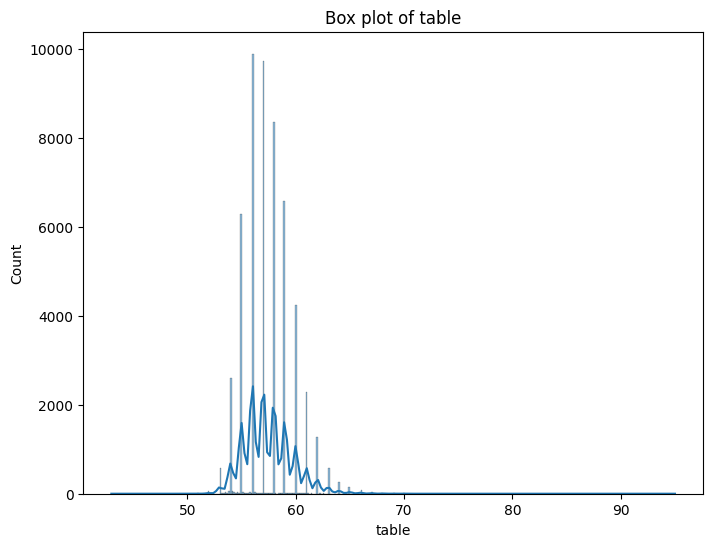

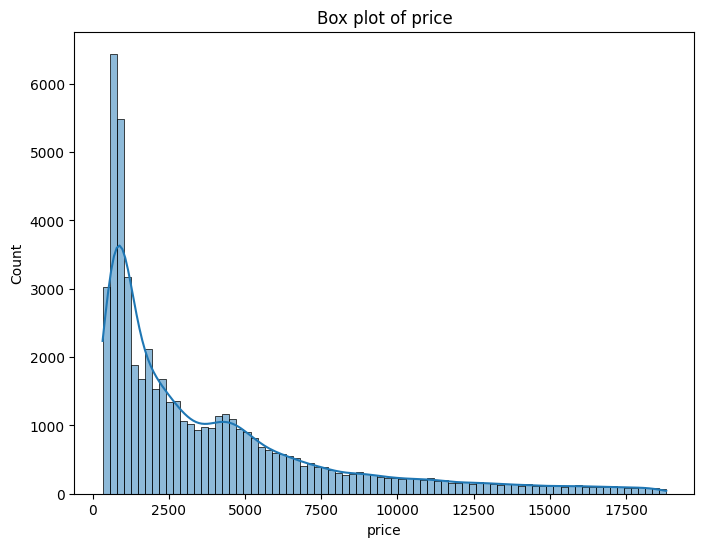

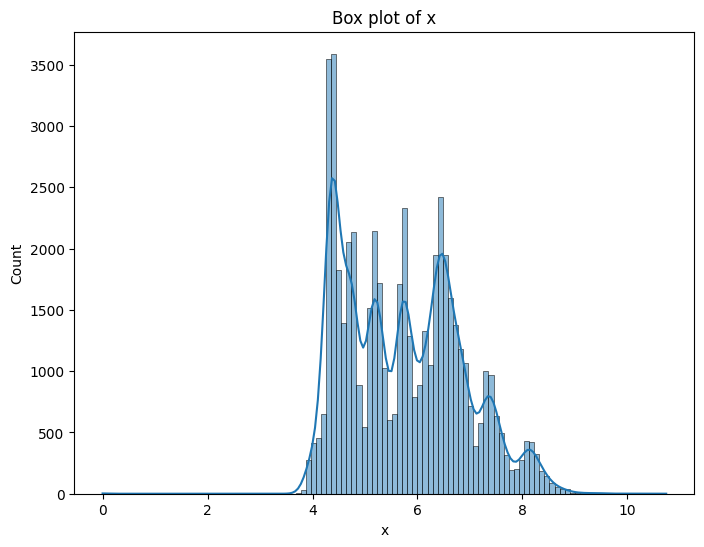

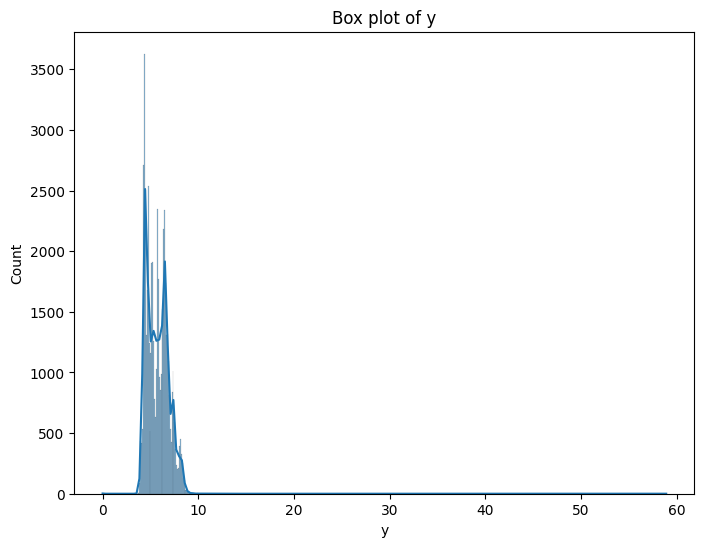

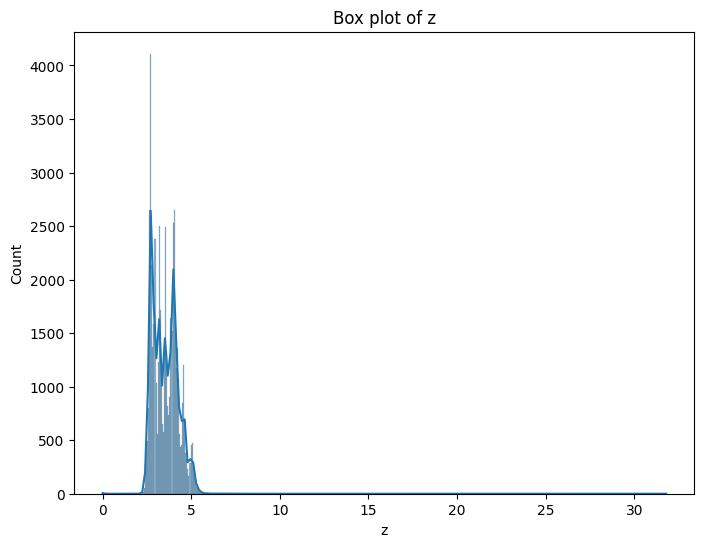

In [40]:
numerical_col=df.select_dtypes(include=np.number).columns

for col in numerical_col:
  plt.figure(figsize=(8,6))
  sns.histplot(df[col],kde=True)
  plt.title(f"Box plot of {col}")
  plt.show()



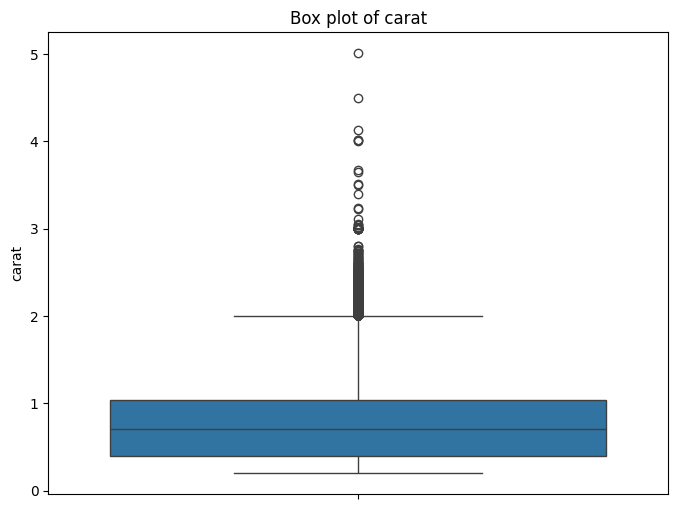

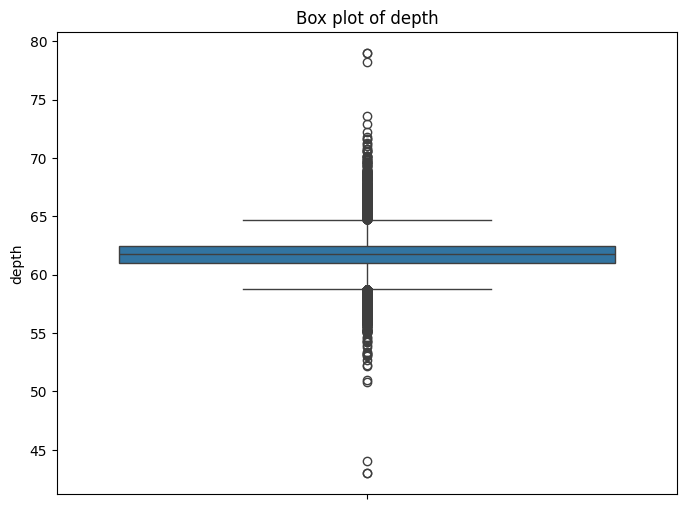

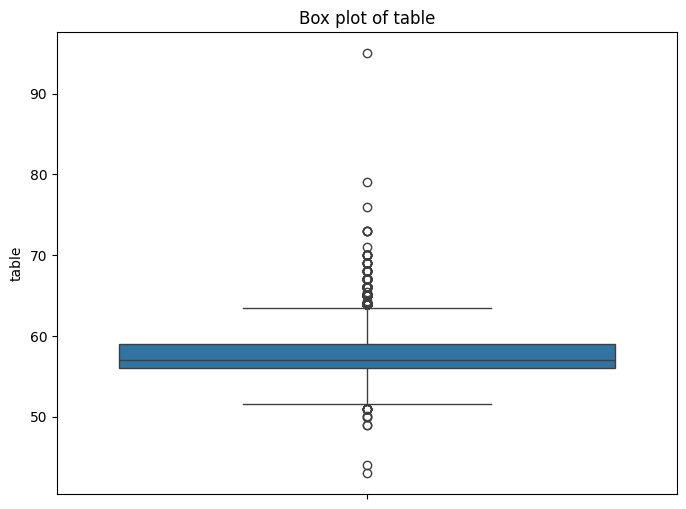

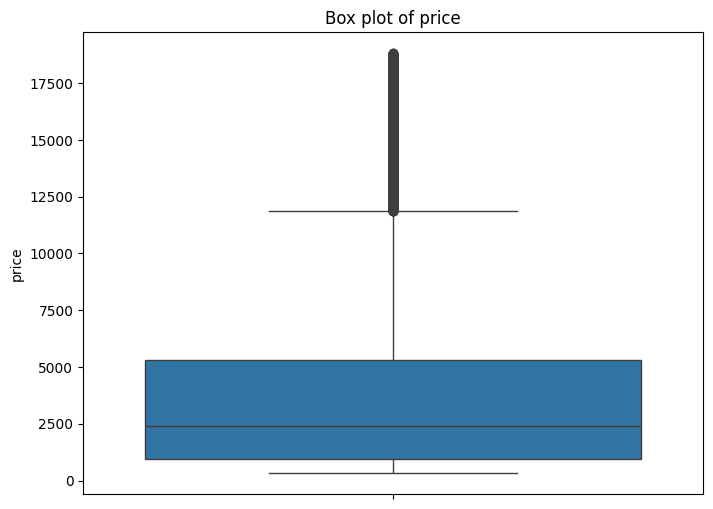

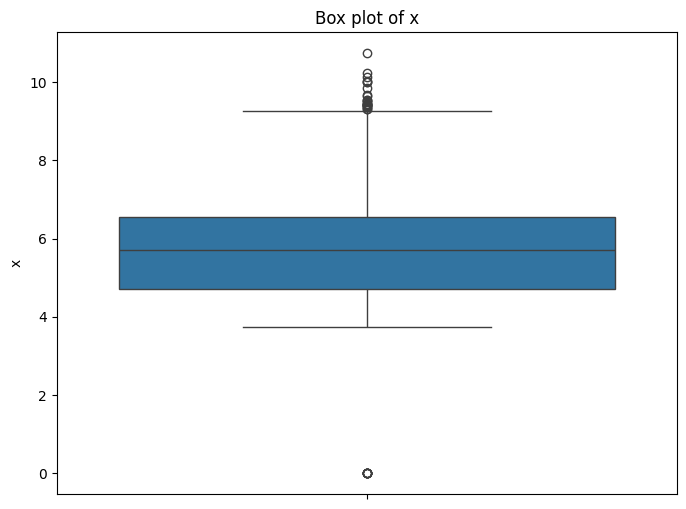

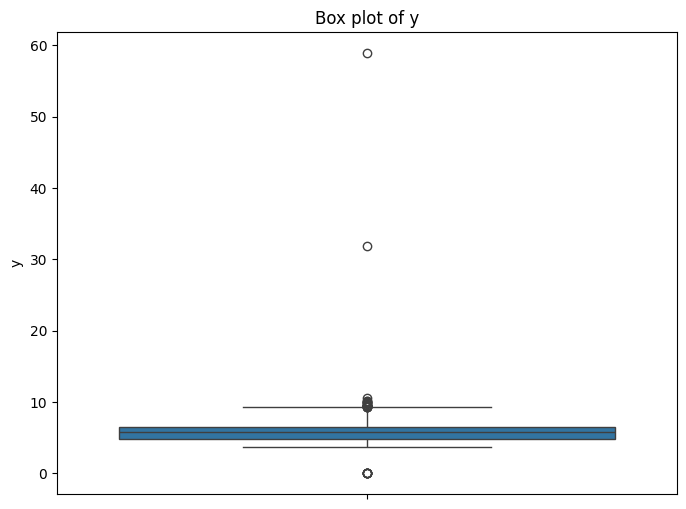

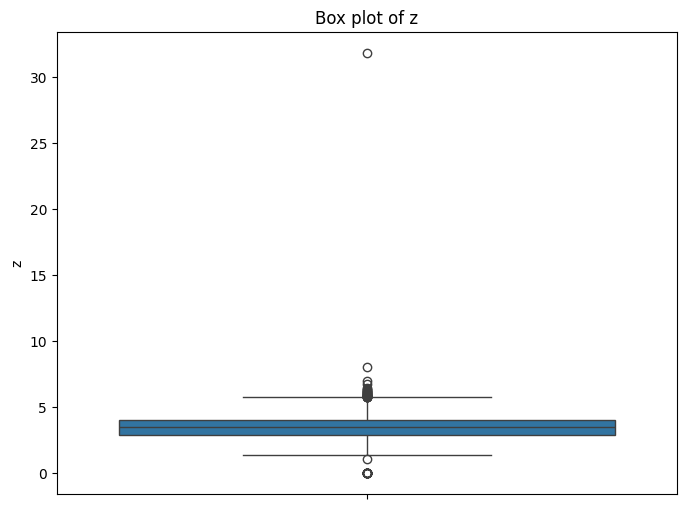

In [41]:
numerical_col=df.select_dtypes(include=np.number).columns

for col in numerical_col:
  plt.figure(figsize=(8,6))
  sns.boxplot(y=df[col])
  plt.title(f"Box plot of {col}")
  plt.show()


In [42]:
from scipy.stats.mstats import winsorize
for col in ['depth', 'table']:
  df[col] = winsorize(df[col], limits=(0.05, 0.05))



In [43]:
from sklearn.preprocessing import OrdinalEncoder
OrdinalEncoder()
df['cut']=OrdinalEncoder().fit_transform(df[['cut']]).astype(int)
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1,E,VS1,59.3,61.0,327,4.05,4.07,2.31
3,0.29,3,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [44]:
from sklearn.preprocessing import OrdinalEncoder
oe=OrdinalEncoder()
df[['cut','color','clarity']]=oe.fit_transform(df[['cut','color','clarity']])
df.head()


,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,2.0,1.0,3.0,61.5,55.0,326,3.95,3.98,2.43
1,0.21,3.0,1.0,2.0,59.8,61.0,326,3.89,3.84,2.31
2,0.23,1.0,1.0,4.0,59.3,61.0,327,4.05,4.07,2.31
3,0.29,3.0,5.0,5.0,62.4,58.0,334,4.20,4.23,2.63
4,0.31,1.0,6.0,3.0,63.3,58.0,335,4.34,4.35,2.75


In [45]:
columns=['carat','depth','table','x','y','z','price']
for col in columns:
  df[col]=np.log1p(df[col])
df.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.207014,2.0,1.0,3.0,4.135167,4.025352,5.789960,1.599388,1.605430,1.232560
1,0.190620,3.0,1.0,2.0,4.107590,4.127134,5.789960,1.587192,1.576915,1.196948
2,0.207014,1.0,1.0,4.0,4.099332,4.127134,5.793014,1.619388,1.623341,1.196948
3,0.254642,3.0,5.0,5.0,4.149464,4.077537,5.814131,1.648659,1.654411,1.289233
4,0.270027,1.0,6.0,3.0,4.163560,4.077537,5.817111,1.675226,1.677097,1.321756


In [46]:
X=df.drop(columns=['price'],axis=1)
y=df['price']

In [47]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)





In [48]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [49]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input

In [50]:
model=Sequential()
model.add(Input(shape=(9,)))
model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))
model.add(Dense(1,activation='linear'))

In [51]:
model.compile(optimizer='adam',loss='mse',metrics=['mae','mse','r2_score'])

In [52]:
learned=model.fit(X_train,y_train,epochs=100,batch_size=32,verbose=1,validation_data=(X_test,y_test))

Epoch 1/100
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - loss: 7.4388 - mae: 1.6578 - mse: 7.4388 - r2_score: -6.3395 - val_loss: 0.0582 - val_mae: 0.1776 - val_mse: 0.0582 - val_r2_score: 0.9435
Epoch 2/100
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1026 - mae: 0.1823 - mse: 0.1026 - r2_score: 0.9013 - val_loss: 0.0452 - val_mae: 0.1586 - val_mse: 0.0452 - val_r2_score: 0.9561
Epoch 3/100
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0566 - mae: 0.1596 - mse: 0.0566 - r2_score: 0.9452 - val_loss: 0.0387 - val_mae: 0.1484 - val_mse: 0.0387 - val_r2_score: 0.9624
Epoch 4/100
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0415 - mae: 0.1541 - mse: 0.0415 - r2_score: 0.9596 - val_loss: 0.0374 - val_mae: 0.1477 - val_mse: 0.0374 - val_r2_score: 0.9637
Epoch 5/100
1349/1349 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.0370 - mae: 0.1447 - mse: 0.0370 - r2_score: 0.9642 - val_loss: 0.0320 - val_mae: 0.1357 - val_mse: 0.0320 - val_r2_score: 0.9689
Epoch 6/100
1349/1349 

In [53]:
loss,mae,mse,r2=model.evaluate(X_test,y_test,verbose=0)
print(loss)
print(mae)
print(mse)
print(r2)

0.00904036220163107
0.06903928518295288
0.00904036220163107
0.9912256598472595


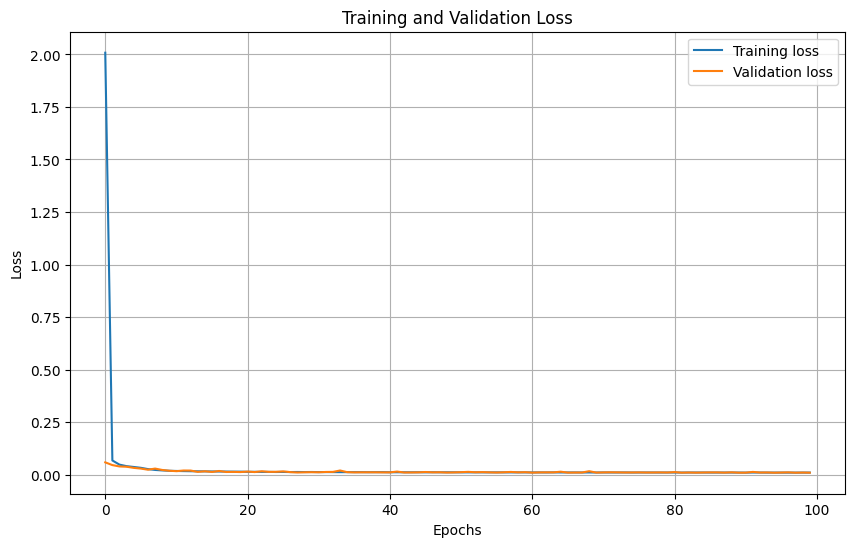

In [54]:
plt.figure(figsize=(10,6))
plt.plot(learned.history['loss'],label='Training loss')
plt.plot(learned.history['val_loss'],label='Validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

In [55]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,797 (38.27 KB)

 Trainable params: 3,265 (12.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,532 (25.52 KB)